In [1]:
import matplotlib.pyplot as plt
from jax.nn import sigmoid
from glm import *
numpyro.set_host_device_count(4)
plt.style.use("ggplot")

In [2]:
jax.devices()

[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3)]

# **Regresión lineal**

In [3]:
n = 1000
p = 4
sigma = 2.0
X = 10 + 20 * np.random.rand(n,p)
X = np.hstack((np.ones((n,1)),X))
beta = np.array([2.5, 0.0, -3.5, 0.0, 1.0])
y  = X @ beta + 2.0*np.random.randn(n)

X = jnp.array(X)
y = jnp.array(y)

In [4]:
beta_prior = dist.Normal(0.0, 10.0)
sigma_prior = dist.HalfNormal(10.0)
baye_lr = BayesianLinearRegression(beta_prior=beta_prior, sigma_prior=sigma_prior, burn_in=2000, num_samples=4000, num_chains=4, seed=18081997)

In [5]:
baye_lr.fit(X, y)

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

In [7]:
baye_lr.summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      2.40      0.45      2.40      1.68      3.16   7250.23      1.00
   beta[1]     -0.00      0.01     -0.00     -0.02      0.01  11637.89      1.00
   beta[2]     -3.50      0.01     -3.50     -3.51     -3.48  11222.54      1.00
   beta[3]     -0.01      0.01     -0.01     -0.02      0.01  11897.18      1.00
   beta[4]      1.01      0.01      1.01      1.00      1.03  12731.64      1.00
     sigma      1.91      0.04      1.91      1.84      1.98  14246.90      1.00

Number of divergences: 0


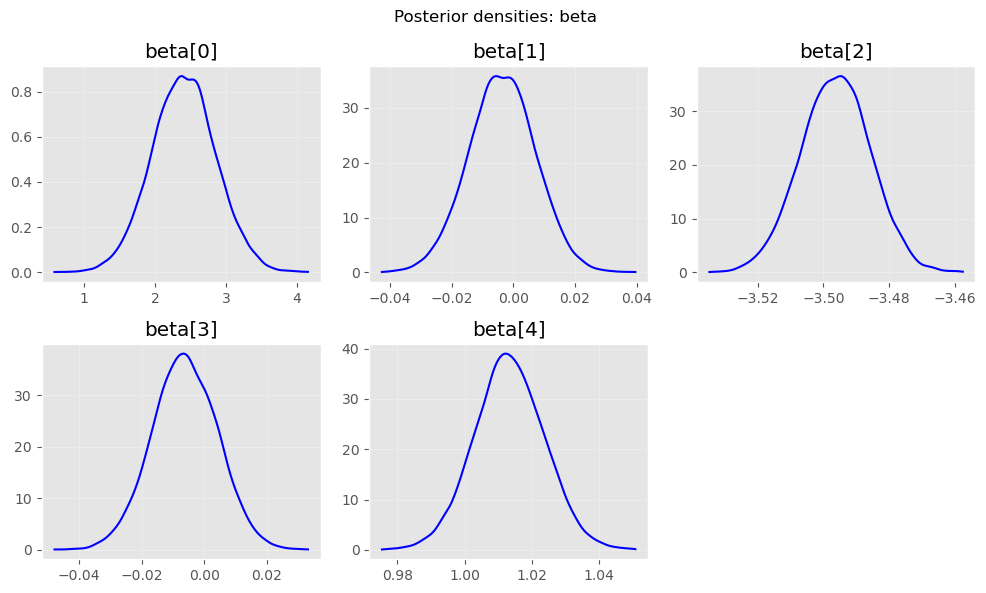

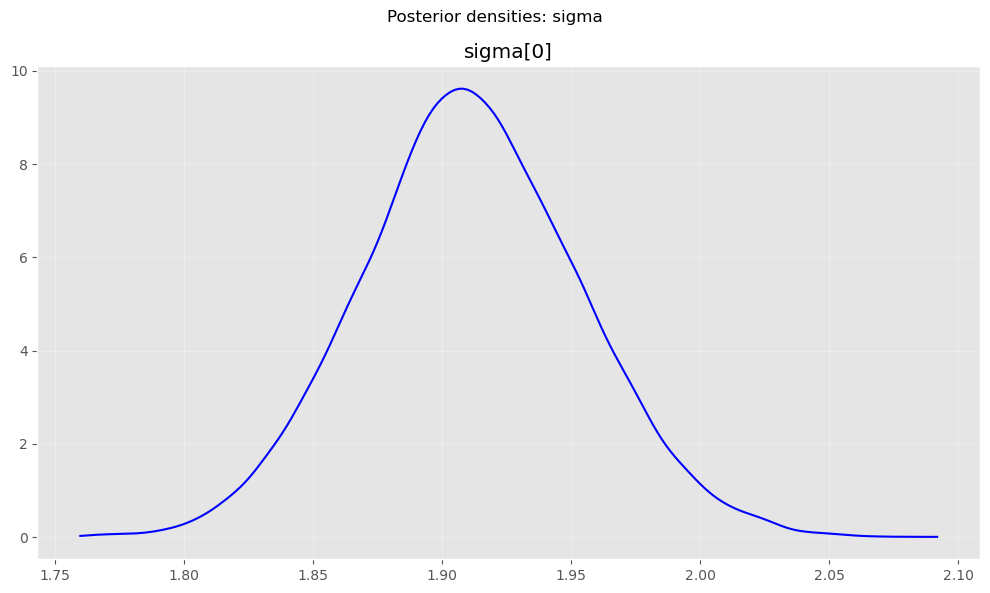

In [8]:
baye_lr.plot_parameter_densities()

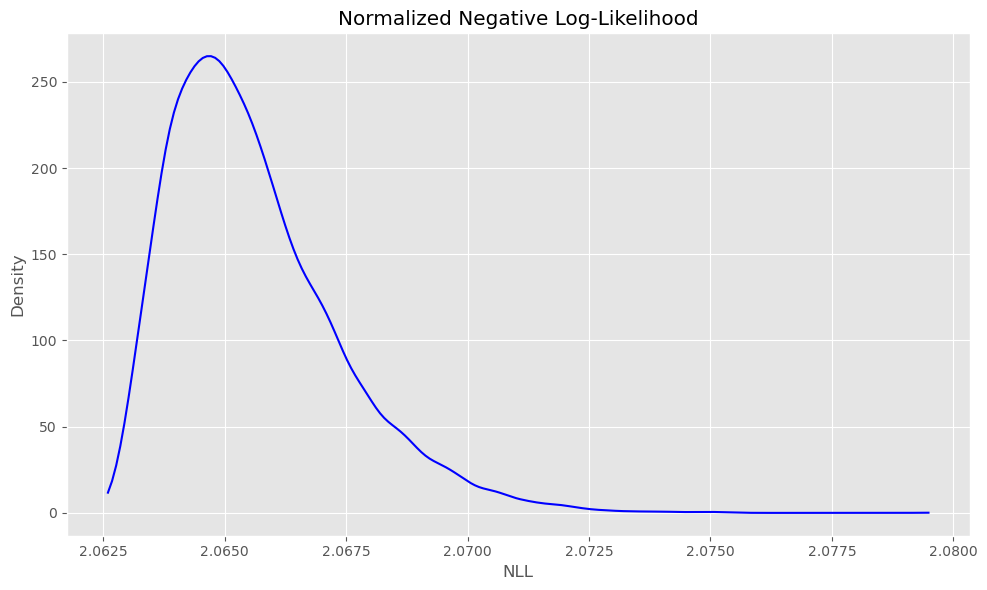

In [9]:
baye_lr.plot_nll_density(X, y)

In [6]:
baye_lr.summary_metrics(X, y)


Model Summary Metrics
           mean           std     median         5%        95%     plugin
NNLL  2.1421673  0.0017612547  2.1418328  2.1399572   2.145498  2.1391354
MSE   4.2438273   0.013746293  4.2408977   4.227221   4.270378  4.2222123
MAE   1.6355859   0.003546517  1.6349976  1.6309218  1.6421986  1.6312512


# **Regresión Laplace**

In [11]:
beta_prior = dist.Normal(0.0, 1.0)
b_prior = dist.HalfCauchy(10.0)
baye_lapr = BayesianLaplaceRegression(beta_prior=beta_prior, b_prior=b_prior, burn_in=2000, num_samples=4000, num_chains=4, seed=18081997)

In [12]:
baye_lapr.fit(X, y)

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

In [13]:
baye_lapr.summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         b      1.53      0.05      1.52      1.44      1.60  11451.40      1.00
   beta[0]      2.46      0.42      2.47      1.78      3.17   6257.77      1.00
   beta[1]     -0.00      0.01     -0.00     -0.02      0.01   8619.77      1.00
   beta[2]     -3.50      0.01     -3.50     -3.51     -3.48   9494.70      1.00
   beta[3]     -0.01      0.01     -0.01     -0.03      0.00   9876.60      1.00
   beta[4]      1.02      0.01      1.02      1.00      1.03   9745.04      1.00

Number of divergences: 0


In [14]:
baye_lapr.summary_metrics(X, y, return_data=False)


Laplace Regression Summary Metrics
           mean           std     median         5%        95%     plugin
NNLL  2.1137521  0.0020501493  2.1133933  2.1110961   2.117579  2.2117994
MSE   3.6446292    0.01358235  3.6419861    3.62777   3.670388  3.6263752
MAE   1.5221134  0.0029390636  1.5215693  1.5184134  1.5276846  1.5186529


In [15]:
baye_lr.summary_metrics(X, y)


Model Summary Metrics
           mean           std     median         5%        95%     plugin
NNLL  2.0656106  0.0017512119  2.0652752  2.0633998  2.0689769  2.7303388
MSE   3.6413238   0.011700481   3.638897   3.627008  3.6641042  3.6228008
MAE   1.5232052  0.0033635593  1.5226213  1.5188107  1.5294849  1.5195875


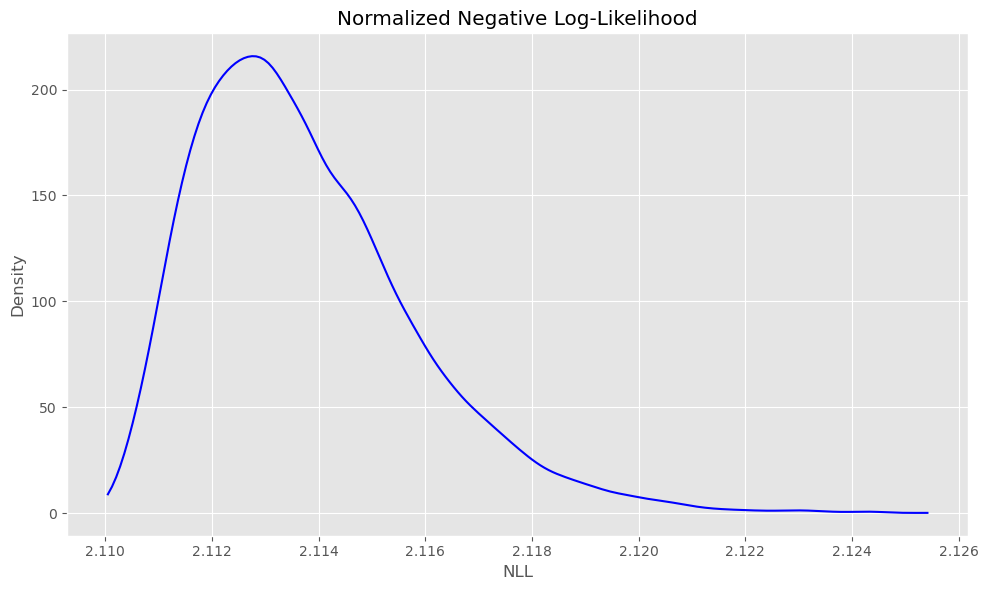

In [16]:
baye_lapr.plot_nll_density(X, y)

# **Laplace vs Normal**

In [17]:
n = 2000
p = 2

# =========================================================
# DATA
# =========================================================

X = np.random.randn(n, p)
X = np.hstack((np.ones((n,1)), X))  # intercepto

beta_true = np.array([1.0, 2.0, -1.5])

# señal
mu = X @ beta_true

# =========================================================
# ruido base (gaussiano)
# =========================================================

noise = 0.5 * np.random.randn(n)

# =========================================================
# OUTLIERS (clave del experimento)
# =========================================================

outlier_idx = np.random.choice(n, size=int(0.05*n), replace=False)

noise[outlier_idx] += np.random.normal(0, 10, size=len(outlier_idx))
# 👆 ruido brutal en pocos puntos

y = mu + noise

# =========================================================
# JAX
# =========================================================

X = jnp.array(X)
y = jnp.array(y)

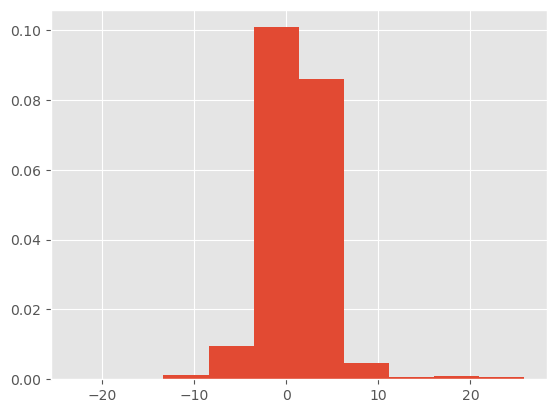

In [21]:
plt.hist(y, density=True)
plt.show()

In [23]:
model_normal = BayesianLinearRegression(num_samples=4000, burn_in=2000, num_chains=4)
model_laplace = BayesianLaplaceRegression(num_samples=4000, burn_in=2000, num_chains=4)

model_normal.fit(X, y)
model_laplace.fit(X, y)

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

In [25]:
df_normal = model_normal.summary_metrics(X, y, return_data=True)
df_laplace = model_laplace.summary_metrics(X, y, return_data=True)


Model Summary Metrics
           mean           std      median          5%         95%      plugin
NNLL  2.2453086  0.0007016956    2.245152   2.2444897   2.2466624   3.5243845
MSE   5.2187276   0.006439584     5.21708   5.2117825    5.231409    5.210891
MAE   0.7799181  0.0073425206  0.77830327  0.77123797  0.79410625  0.77422833

Laplace Regression Summary Metrics
           mean            std     median          5%        95%      plugin
NNLL   1.432376  0.00072992785  1.4322093   1.4315283  1.4337915   1.4628209
MSE   5.2196965   0.0029791263   5.219527   5.2152014    5.22492   5.2189145
MAE   0.7702681   0.0004881812   0.770141  0.76973647  0.7712264  0.76967376


# **Regresión Logística**

In [26]:
n = 5000
p = 4
sigma = 2.0
X = 10 * np.random.rand(n,p)
X = np.hstack((np.ones((n,1)),X))
beta = np.array([5.5, 2.3, -1.5, 0.0, 0.0])
probs = sigmoid(X @ beta)
key = random.PRNGKey(18081997)
y = dist.Bernoulli(probs).sample(key)
X = jnp.array(X)
y = jnp.array(y)

In [29]:
beta_prior = dist.Normal(0, 10.0)
log_reg = BayesianLogisticRegression(beta_prior=beta_prior, num_samples=5000, burn_in=2000, num_chains=4,seed=145)
log_reg.fit(X, y)

  0%|          | 0/7000 [00:00<?, ?it/s]

  0%|          | 0/7000 [00:00<?, ?it/s]

  0%|          | 0/7000 [00:00<?, ?it/s]

  0%|          | 0/7000 [00:00<?, ?it/s]

In [30]:
log_reg.summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      5.26      0.39      5.25      4.63      5.89   8366.92      1.00
   beta[1]      2.24      0.11      2.23      2.05      2.42   9190.44      1.00
   beta[2]     -1.47      0.07     -1.47     -1.59     -1.35   8011.55      1.00
   beta[3]      0.03      0.03      0.03     -0.02      0.07  13401.46      1.00
   beta[4]      0.00      0.03      0.00     -0.04      0.05  11650.49      1.00

Number of divergences: 0


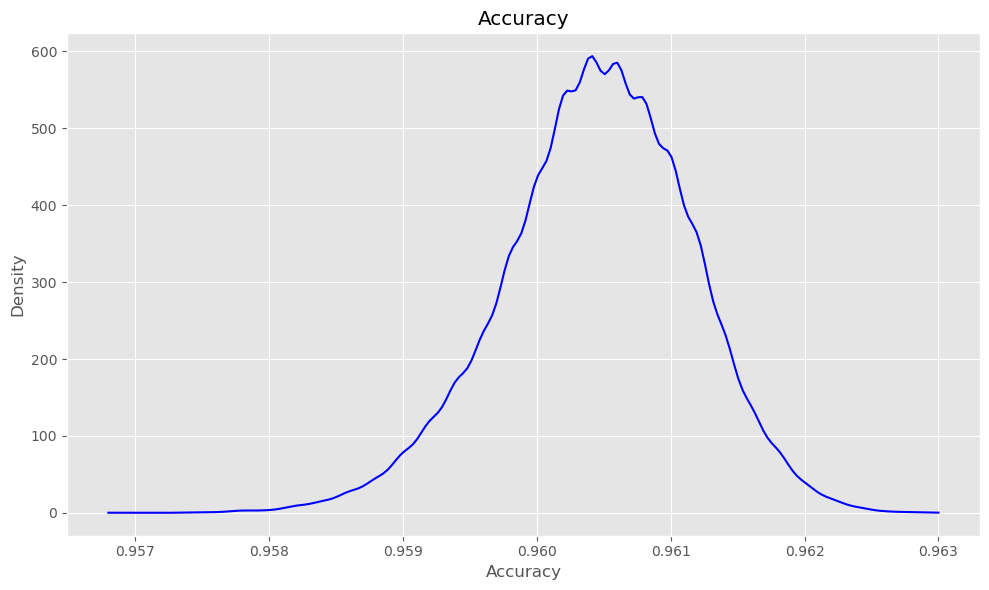

In [31]:
log_reg.plot_accuracy_density(X, y)

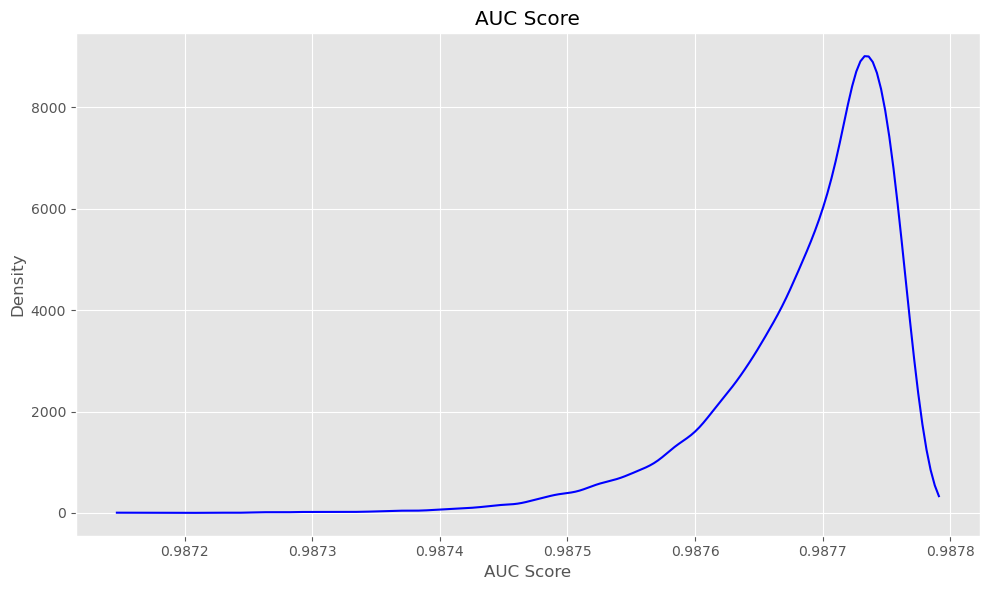

In [32]:
log_reg.plot_auc_density(X, y)

In [33]:
log_reg.summary_metrics(X, y)

,mean,std,median,5%,95%,plugin
NNLL,0.09476979,0.00031502676,0.09470661,0.09438709,0.09537927,0.094273
AUC,0.9876884,6.969985e-05,0.9877083,0.987549,0.9877636,0.987758
ACC,0.96044713,0.0007001833,0.9604,0.95919997,0.96159995,0.9608


# **Regresión Poisson y Binomial Negativa**

In [7]:
n = 5000
p = 4
sigma = 2.0
X = 10 * np.random.rand(n,p)
X = np.hstack((np.ones((n,1)),X))
beta = np.array([0.5, -0.1, 0.5, 0.0, 0.03])
rates = jnp.exp(X @ beta)
y = dist.Poisson(rates).sample(random.PRNGKey(0))
X = jnp.array(X)
y = jnp.array(y)

In [37]:
beta_prior = dist.Normal(0, 10.0)
poi_model = BayesianPoissonRegression(num_samples=5000, burn_in=3000, num_chains=4)
poi_model.fit(X, y)

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

In [38]:
poi_model.summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   beta[0]      0.50      0.01      0.50      0.48      0.52   5180.13      1.00
   beta[1]     -0.10      0.00     -0.10     -0.10     -0.10  14084.97      1.00
   beta[2]      0.50      0.00      0.50      0.50      0.50   6244.85      1.00
   beta[3]     -0.00      0.00     -0.00     -0.00      0.00  14612.05      1.00
   beta[4]      0.03      0.00      0.03      0.03      0.03  15474.69      1.00

Number of divergences: 0


In [39]:
poi_model.summary_metrics(X, y)


Summary Normalized Negative Log-Likelihood
------------------------------------------
beta_hat NLL: 2.7142

mean      : 2.7147
std       : 0.0003
median    : 2.7146
5%        : 2.7143
95%       : 2.7153


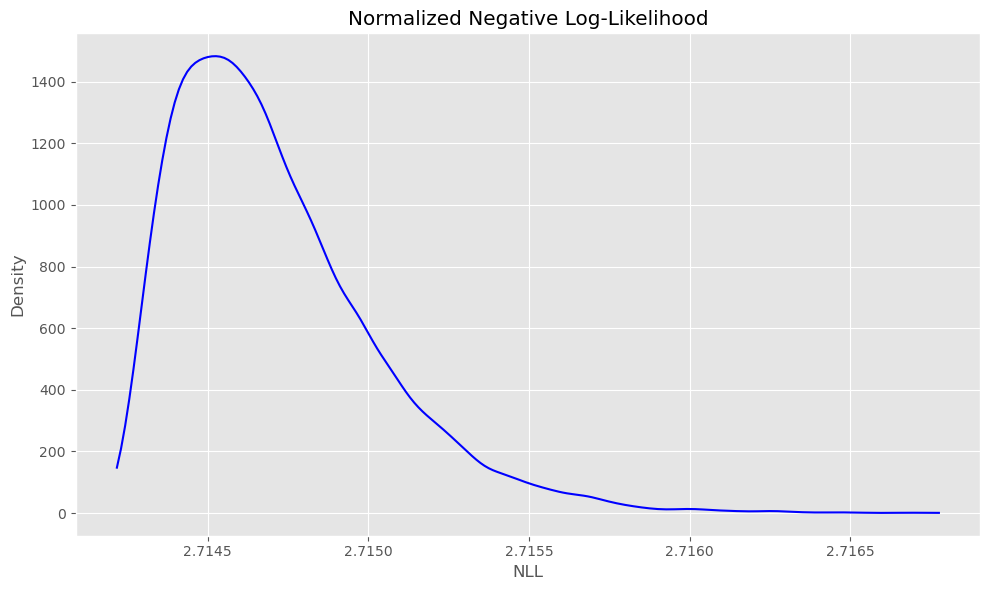

In [40]:
poi_model.plot_nll_density(X, y)

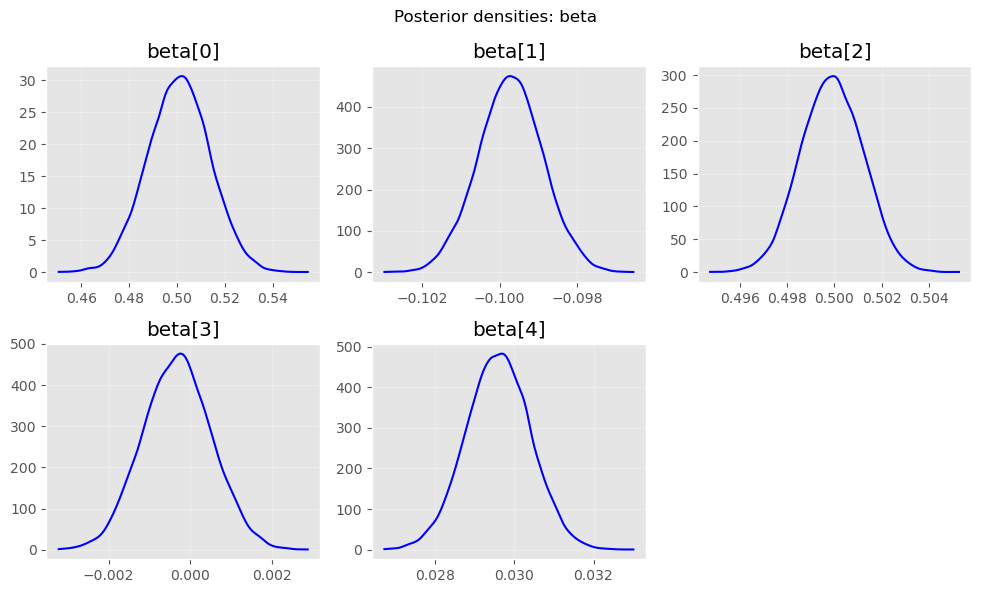

In [41]:
poi_model.plot_parameter_densities()

In [8]:
n = 5000
p = 4
X = 10 * np.random.rand(n,p)
X = np.hstack((np.ones((n,1)),X))
beta = np.array([0.5, -0.1, 0.5, 0.0, 0.03])
rates = jnp.exp(X @ beta)
alpha = 0.5
y = dist.NegativeBinomial2(rates, alpha).sample(random.PRNGKey(1808))
X = jnp.array(X)
y = jnp.array(y)

In [9]:
bin_neg_model = BayesianNegBinomRegression(num_samples=5000, burn_in=3000, num_chains=4)
bin_neg_model.fit(X, y)

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

In [10]:
bin_neg_model.summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     alpha      0.50      0.01      0.50      0.49      0.52  17525.61      1.00
   beta[0]      0.55      0.08      0.55      0.43      0.68   9869.51      1.00
   beta[1]     -0.10      0.01     -0.10     -0.11     -0.09  15359.62      1.00
   beta[2]      0.49      0.01      0.49      0.48      0.50  14852.09      1.00
   beta[3]      0.00      0.01      0.00     -0.01      0.01  14275.95      1.00
   beta[4]      0.03      0.01      0.03      0.02      0.04  14821.97      1.00

Number of divergences: 0


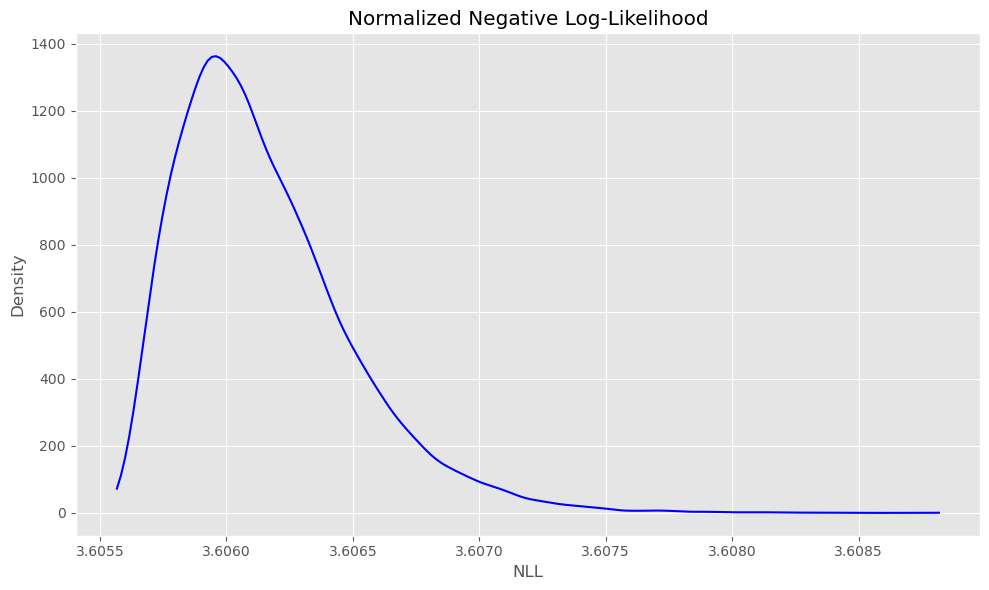

In [11]:
bin_neg_model.plot_nll_density(X, y)

In [12]:
bin_neg_model.summary_metrics(X, y)


Summary Normalized Negative Log-Likelihood
------------------------------------------
beta_hat NLL: 3.6056

mean      : 3.6061
std       : 0.0003
median    : 3.6061
5%        : 3.6057
95%       : 3.6068


In [13]:
poisson_model = BayesianPoissonRegression(num_samples=5000, burn_in=3000, num_chains=4)
poisson_model.fit(X, y)

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

In [14]:
poisson_model.summary_metrics(X, y)


Summary Normalized Negative Log-Likelihood
------------------------------------------
beta_hat NLL: 26.9594

mean      : 26.9598
std       : 0.0003
median    : 26.9598
5%        : 26.9595
95%       : 26.9605


# **Reresión Gamma**

In [15]:
n = 5000
p = 3
alpha = 2.5

X = 10 * np.random.rand(n,p)
X = np.hstack((np.ones((n,1)),X))
beta = np.array([0.8, -1.1, 0.5, 0.0])
mu = jnp.exp(X @ beta)
y = dist.Gamma(alpha, alpha/mu).sample(random.PRNGKey(1808))
X = jnp.array(X)
y = jnp.array(y)

In [16]:
model = BayesianGammaRegression(num_samples=5000, burn_in=3000, num_chains=4)
model.fit(X, y)

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

  0%|          | 0/8000 [00:00<?, ?it/s]

In [17]:
model.summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     alpha      2.46      0.05      2.46      2.38      2.53  17718.97      1.00
   beta[0]      0.78      0.03      0.78      0.74      0.83  10196.01      1.00
   beta[1]     -1.10      0.00     -1.10     -1.10     -1.09  15639.35      1.00
   beta[2]      0.50      0.00      0.50      0.50      0.51  15563.85      1.00
   beta[3]     -0.00      0.00     -0.00     -0.01      0.00  15279.10      1.00

Number of divergences: 0


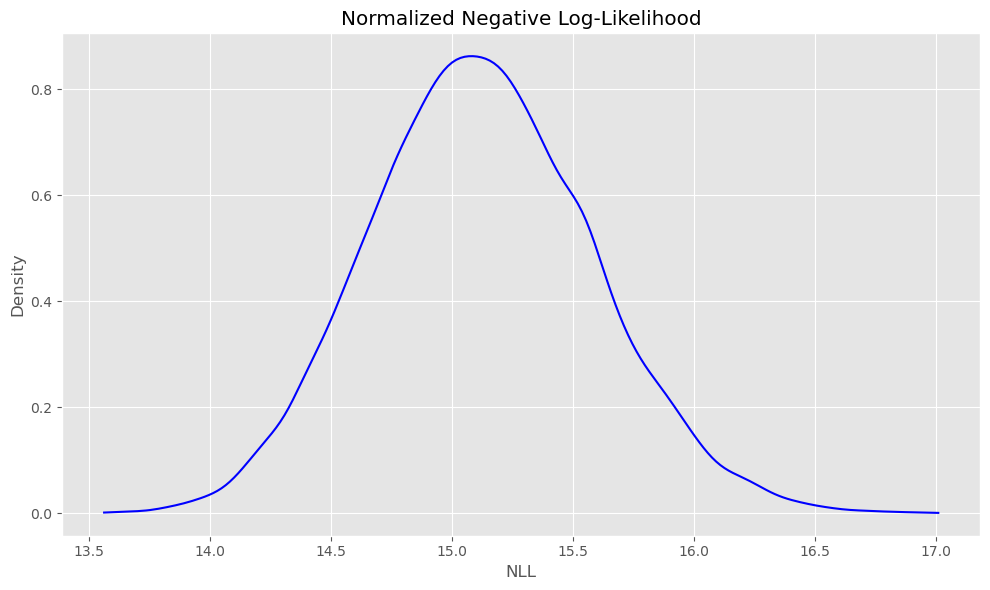

In [18]:
model.plot_nll_density(X, y)

In [19]:
model.summary_metrics(X,y)


Summary Normalized Negative Log-Likelihood
------------------------------------------
beta_hat NLL: 15.1106

mean      : 15.1205
std       : 0.4617
median    : 15.1083
5%        : 14.3834
95%       : 15.9035


In [6]:
n = 5000
p = 3
K = 4   # número de clases

# =========================================================
# DATASET
# =========================================================

X = 10 * np.random.rand(n, p)
X = np.hstack((np.ones((n,1)), X))   # intercepto

# beta: (K, p+1)
beta = np.array([
    [ 0.5, -1.0,  0.3,  0.2],
    [-0.2,  0.8, -0.5,  0.1],
    [ 1.0, -0.3,  0.2, -0.7],
    [-0.5,  0.2,  0.1,  0.5]
])

# =========================================================
# LOGITS
# =========================================================

logits = X @ beta.T

# =========================================================
# PROBABILIDADES (softmax)
# =========================================================

probs = jax.nn.softmax(logits, axis=1)

# =========================================================
# SAMPLE
# =========================================================

key = random.PRNGKey(1808)

y = dist.Categorical(probs=probs).sample(key)

# =========================================================
# CONVERTIR A JAX
# =========================================================

X = jnp.array(X)
y = jnp.array(y)

In [12]:
multinomial_model = BayesianMultinomialRegression(beta_prior=dist.Normal(0,1.0), num_samples=3000, num_chains=4, burn_in=2000, K=4)
multinomial_model.fit(X, y)

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

In [13]:
multinomial_model.summary_metrics(X, y)

,mean,std,median,5%,95%,plugin
NNLL,0.54024273,0.00048780555,0.540174,0.53957576,0.5411355,0.5390638
ACC,0.7647952,0.0013739001,0.76479995,0.7624,0.76699996,0.7654


In [14]:
multinomial_model.summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
 beta[0,0]      0.33      0.51      0.34     -0.48      1.21   6816.45      1.00
 beta[0,1]     -0.94      0.50     -0.95     -1.76     -0.12   6043.17      1.00
 beta[0,2]      0.23      0.50      0.23     -0.57      1.09   5877.22      1.00
 beta[0,3]      0.24      0.50      0.24     -0.57      1.07   5678.81      1.00
 beta[1,0]     -0.59      0.50     -0.59     -1.41      0.23   6408.04      1.00
 beta[1,1]      0.84      0.50      0.84      0.06      1.71   6041.16      1.00
 beta[1,2]     -0.50      0.50     -0.50     -1.30      0.35   5875.24      1.00
 beta[1,3]      0.12      0.50      0.12     -0.72      0.92   5672.83      1.00
 beta[2,0]      1.02      0.52      1.02      0.13      1.85   6920.51      1.00
 beta[2,1]     -0.20      0.50     -0.20     -1.04      0.61   6084.50      1.00
 beta[2,2]      0.13      0.50      0.13     -0.68      0.98   5875.74      1.00
 beta[2,3]     -0.83      0

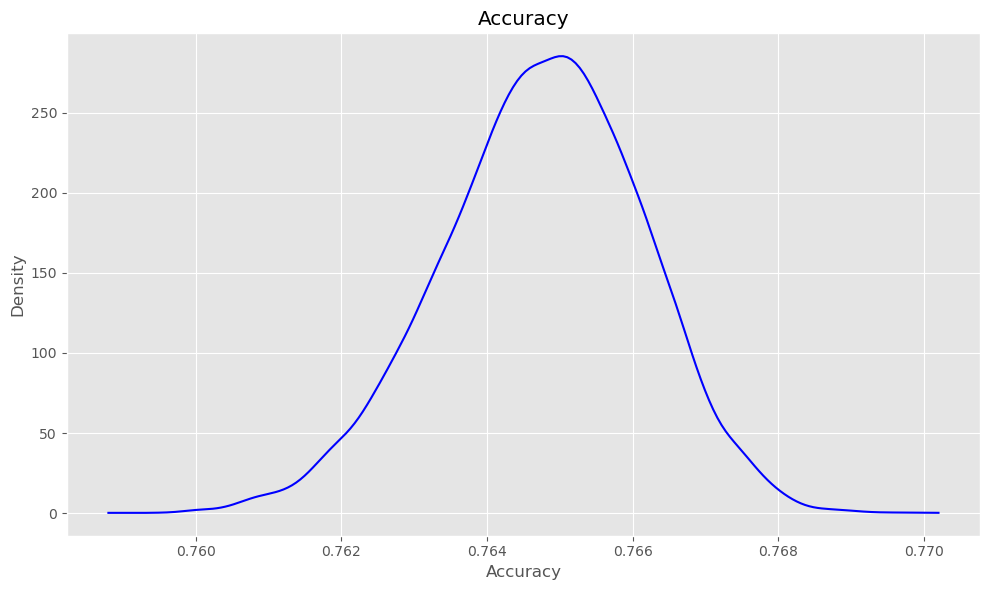

In [11]:
multinomial_model.plot_accuracy_density(X, y)

In [15]:
X, y = generate_rotated_ellipse_data(random.PRNGKey(180819597), n=2000, noise=0.05)

NameError: name 'generate_rotated_ellipse_data' is not defined

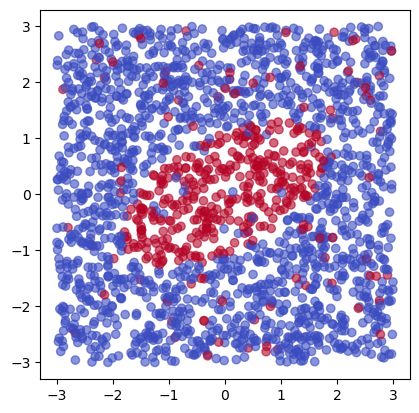

In [50]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", alpha=0.6)
plt.gca().set_aspect('equal')
plt.show()

In [51]:
def bnn_model(X, y=None, hidden_dim=10, tau=1.0):

    n, d = X.shape

    # -------------------------
    # Priors
    # -------------------------
    W1 = numpyro.sample("W1", dist.Normal(0, tau).expand([d, hidden_dim]))
    b1 = numpyro.sample("b1", dist.Normal(0, tau).expand([hidden_dim]))

    W2 = numpyro.sample("W2", dist.Normal(0, tau).expand([hidden_dim]))
    b2 = numpyro.sample("b2", dist.Normal(0, tau))

    # -------------------------
    # Forward
    # -------------------------
    a = jnp.tanh(jnp.dot(X, W1) + b1)
    logits = jnp.dot(a, W2) + b2

    # -------------------------
    # Likelihood
    # -------------------------
    with numpyro.plate("data", n):

        numpyro.sample("target", dist.Bernoulli(logits=logits), obs=y)

In [52]:
kernel = NUTS(bnn_model)
mcmc = MCMC(kernel, num_warmup=2000, num_samples=5000, num_chains=3, chain_method="parallel")

rng_key = random.PRNGKey(12756)
mcmc.run(rng_key, X=X, y=y)


  0%|          | 0/7000 [00:00<?, ?it/s]

  0%|          | 0/7000 [00:00<?, ?it/s]

  0%|          | 0/7000 [00:00<?, ?it/s]

In [12]:
samples = mcmc.get_samples()

In [ ]:
def predict_proba(samples, X):

    W1 = samples["W1"]
    b1 = samples["b1"]
    W2 = samples["W2"]
    b2 = samples["b2"]

    a = jnp.tanh(jnp.matmul(X[None, :, :], W1) + b1[:, None, :])
    logits = jnp.matmul(a, W2[:, :, None]).squeeze(-1) + b2[:, None]

    probs = jax.nn.sigmoid(logits)

    return probs

In [37]:
probs = predict_proba(samples, X)

mean_probs = probs.mean(axis=0)
y_pred = (mean_probs >= 0.5)

accuracy = (y_pred == y).mean()

In [38]:
accuracy

Array(0.93750006, dtype=float32)

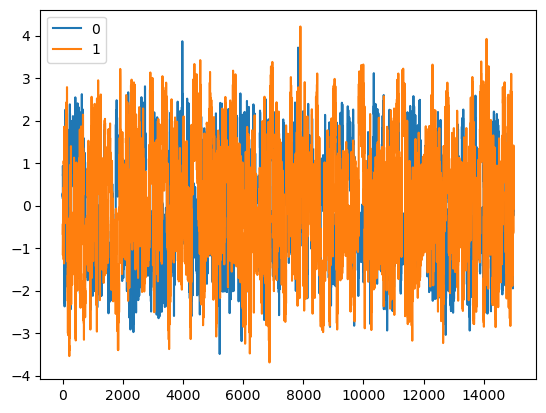

In [39]:
pd.DataFrame(samples['W1'][:, :, 2]).plot()
plt.show()

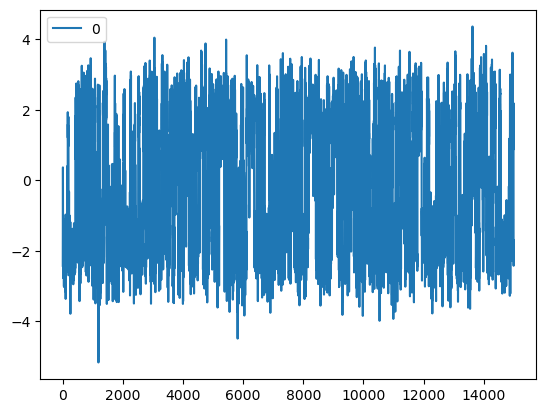

In [40]:
pd.DataFrame(samples['b1'][:,8]).plot()
plt.show()

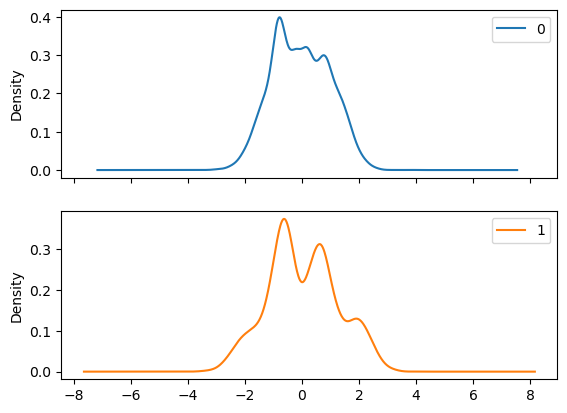

In [41]:
pd.DataFrame(samples['W1'][:, :, 2]).plot.kde(subplots=True)
plt.show()

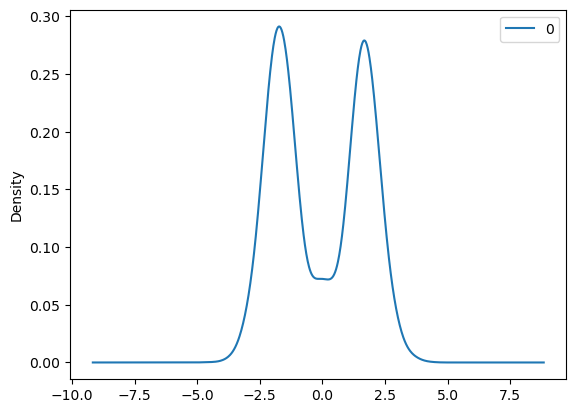

In [101]:
pd.DataFrame(samples['b1'][:, 6]).plot.kde(subplots=True)
plt.show()